# Fluxo Simplificado do invest-robô

Este notebook usa o `simple_quant` com a separação correta:

- a base principal tem uma linha por `data`
- `preco_*` guarda os preços dos papéis
- `YFINANCE_FEATURES` e `BCB_FEATURES` ficam como colunas únicas por data
- `ma7` e `ma21` são criadas só na base de modelagem do ticker escolhido

Fluxo:

1. atualizar a base
2. conferir o formato wide
3. fazer EDA
4. preparar a base de modelagem para um ticker-alvo
5. treinar e avaliar
6. salvar artefatos
7. escorar e registrar no banco


In [3]:
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)

from simple_quant import config
from simple_quant.data_builder import MiningDataBuilder
from simple_quant.db import (
    init_db,
    list_datasets,
    list_models,
    list_scores,
    load_dataset,
    save_dataset,
    save_model_record,
    save_score_row,
    get_connection
)
from simple_quant.features import (
    get_feature_columns,
    get_scoring_row,
    infer_horizon_from_target,
    prepare_modeling_data,
    split_train_test,
)
from simple_quant.models import (
    find_best_fbeta_threshold,
    load_model_artifacts,
    save_model_artifacts,
    score_row,
    train_model,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)


In [4]:
init_db()
config.DB_PATH

WindowsPath('C:/Users/Guilherme/Documents/Projetos/invest-robô/data/simple_quant.db')

In [5]:
conn = get_connection()

In [6]:
pd.read_sql("SELECT * FROM dataset_base_mineracao", conn)

,data,preco_brap4_sa,petroleo_wti,preco_cmin3_sa,preco_csna3_sa,dxy,ouro,preco_ggbr4_sa,preco_goau4_sa,cobre,...,minerio_ferro,dolar,preco_usim5_sa,preco_vale3_sa,ibovespa,sp500,vix,selic_dia,ipca_mensal,ts
0,2025-01-02 00:00:00,13.900052,73.129997,4.462106,8.42,109.389999,2658.899902,17.180902,7.234953,3.9885,...,100.610001,6.3000,5.16,47.932835,120125.0,5868.549805,17.930000,0.045513,NaN,2026-04-26 00:59:17.784905
1,2025-01-03 00:00:00,13.503872,73.959999,4.320452,8.21,108.949997,2645.000000,16.614920,6.977329,4.0395,...,99.440002,6.1510,4.85,47.040447,118533.0,5942.470215,16.129999,0.045513,NaN,2026-04-26 00:59:17.784905
2,2025-01-06 00:00:00,13.546019,73.559998,4.435546,8.53,108.260002,2638.399902,17.296019,7.206328,4.1270,...,99.440002,6.1807,5.09,46.439629,120022.0,5975.379883,16.040001,0.045513,NaN,2026-04-26 00:59:17.784905
3,2025-01-07 00:00:00,13.411148,74.250000,4.265083,8.36,108.540001,2656.699951,17.209681,7.149079,4.1605,...,97.839996,6.1155,5.08,45.989017,121163.0,5909.029785,17.820000,0.045513,NaN,2026-04-26 00:59:17.784905
4,2025-01-08 00:00:00,13.183555,73.320000,4.140164,7.76,109.089996,2664.500000,16.883522,7.005953,4.2275,...,97.739998,6.1009,4.88,45.547237,119625.0,5918.250000,17.700001,0.045513,NaN,2026-04-26 00:59:17.784905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,2026-04-21 00:00:00,25.180000,92.129997,5.040000,6.82,98.410004,4698.399902,21.440001,9.450000,6.0015,...,107.050003,4.9524,7.27,88.730003,196132.0,7064.009766,19.500000,0.054266,0.33,2026-04-26 00:59:17.784905
336,2026-04-22 00:00:00,24.580000,92.959999,4.940000,6.64,98.589996,4732.500000,21.719999,9.550000,6.1200,...,107.110001,5.0080,7.25,87.220001,192889.0,7137.899902,18.920000,0.054266,0.33,2026-04-26 00:59:17.784905
337,2026-04-23 00:00:00,24.059999,95.849998,4.800000,6.39,98.800003,4705.100098,21.680000,9.520000,6.0755,...,107.059998,4.9849,7.21,85.970001,191378.0,7108.399902,19.309999,0.054266,0.33,2026-04-26 00:59:17.784905
338,2026-04-24 00:00:00,23.950001,94.400002,4.740000,6.43,98.510002,4722.299805,21.770000,9.490000,6.0235,...,107.099998,5.0308,7.61,85.870003,190745.0,7165.080078,18.709999,0.054266,0.33,2026-04-26 00:59:17.784905


## Atualizar a base

In [5]:
builder = MiningDataBuilder(start_date=config.DEFAULT_START_DATE)
df_base = builder.build()

In [6]:
df_base.head()

,data,preco_brap4_sa,petroleo_wti,preco_cmin3_sa,preco_csna3_sa,dxy,ouro,preco_ggbr4_sa,preco_goau4_sa,cobre,...,minerio_ferro,dolar,preco_usim5_sa,preco_vale3_sa,ibovespa,sp500,vix,selic_dia,ipca_mensal,ts
0,2025-01-02,13.900052,73.129997,4.462106,8.42,109.389999,2658.899902,17.180902,7.234953,3.9885,...,100.610001,6.3000,5.16,47.932835,120125.0,5868.549805,17.930000,0.045513,NaN,2026-04-26 00:59:17.784905
1,2025-01-03,13.503872,73.959999,4.320452,8.21,108.949997,2645.000000,16.614920,6.977329,4.0395,...,99.440002,6.1510,4.85,47.040447,118533.0,5942.470215,16.129999,0.045513,NaN,2026-04-26 00:59:17.784905
2,2025-01-06,13.546019,73.559998,4.435546,8.53,108.260002,2638.399902,17.296019,7.206328,4.1270,...,99.440002,6.1807,5.09,46.439629,120022.0,5975.379883,16.040001,0.045513,NaN,2026-04-26 00:59:17.784905
3,2025-01-07,13.411148,74.250000,4.265083,8.36,108.540001,2656.699951,17.209681,7.149079,4.1605,...,97.839996,6.1155,5.08,45.989017,121163.0,5909.029785,17.820000,0.045513,NaN,2026-04-26 00:59:17.784905
4,2025-01-08,13.183555,73.320000,4.140164,7.76,109.089996,2664.500000,16.883522,7.005953,4.2275,...,97.739998,6.1009,4.88,45.547237,119625.0,5918.250000,17.700001,0.045513,NaN,2026-04-26 00:59:17.784905


In [ ]:

save_dataset(
    df_base,
    dataset_name=config.DEFAULT_DATASET_NAME,
    description="Base wide com preco_* e fatores macro por data",
    append = True # alterado
)

print(df_base.shape)
df_base.head()


(340, 24)


,data,preco_brap4_sa,petroleo_wti,preco_cmin3_sa,preco_csna3_sa,dxy,ouro,preco_ggbr4_sa,preco_goau4_sa,cobre,...,minerio_ferro,dolar,preco_usim5_sa,preco_vale3_sa,ibovespa,sp500,vix,selic_dia,ipca_mensal,ts
0,2025-01-02,13.900052,73.129997,4.462106,8.42,109.389999,2658.899902,17.180902,7.234953,3.9885,...,100.610001,6.3000,5.16,47.932835,120125.0,5868.549805,17.930000,0.045513,NaN,2026-04-26 00:59:17.784905
1,2025-01-03,13.503872,73.959999,4.320452,8.21,108.949997,2645.000000,16.614920,6.977329,4.0395,...,99.440002,6.1510,4.85,47.040447,118533.0,5942.470215,16.129999,0.045513,NaN,2026-04-26 00:59:17.784905
2,2025-01-06,13.546019,73.559998,4.435546,8.53,108.260002,2638.399902,17.296019,7.206328,4.1270,...,99.440002,6.1807,5.09,46.439629,120022.0,5975.379883,16.040001,0.045513,NaN,2026-04-26 00:59:17.784905
3,2025-01-07,13.411148,74.250000,4.265083,8.36,108.540001,2656.699951,17.209681,7.149079,4.1605,...,97.839996,6.1155,5.08,45.989017,121163.0,5909.029785,17.820000,0.045513,NaN,2026-04-26 00:59:17.784905
4,2025-01-08,13.183555,73.320000,4.140164,7.76,109.089996,2664.500000,16.883522,7.005953,4.2275,...,97.739998,6.1009,4.88,45.547237,119625.0,5918.250000,17.700001,0.045513,NaN,2026-04-26 00:59:17.784905


In [9]:
list_datasets()


,dataset_name,table_name,description,row_count,updated_at
0,base_mineracao,dataset_base_mineracao,Base wide com preco_* e fatores macro por data,340,2026-04-26T00:59:26.757904


In [10]:
pd.read_sql(f"SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,dataset_registry
1,model_registry
2,score_log
3,sqlite_sequence
4,dataset_base_mineracao


In [11]:
pd.read_sql("SELECT * FROM dataset_registry", conn)

,dataset_name,table_name,description,row_count,updated_at
0,base_mineracao,dataset_base_mineracao,Base wide com preco_* e fatores macro por data,340,2026-04-26T00:59:26.757904


## Conferir o formato da base

In [12]:
price_cols = [col for col in df_base.columns if col.startswith(config.PRICE_COLUMN_PREFIX)]

print("Colunas de preço:", price_cols)
print("Colunas macro:", config.DEFAULT_MACRO_COLS)

sample_cols = ["data", *price_cols[:6], *config.DEFAULT_MACRO_COLS[:5]]
df_base[sample_cols].head()


Colunas de preço: ['preco_brap4_sa', 'preco_cmin3_sa', 'preco_csna3_sa', 'preco_ggbr4_sa', 'preco_goau4_sa', 'preco_klbn11_sa', 'preco_petr4_sa', 'preco_prio3_sa', 'preco_suzb3_sa', 'preco_usim5_sa', 'preco_vale3_sa']
Colunas macro: ['ibovespa', 'dolar', 'minerio_ferro', 'sp500', 'vix', 'dxy', 'cobre', 'ouro', 'petroleo_wti', 'selic_dia', 'ipca_mensal']


,data,preco_brap4_sa,preco_cmin3_sa,preco_csna3_sa,preco_ggbr4_sa,preco_goau4_sa,preco_klbn11_sa,ibovespa,dolar,minerio_ferro,sp500,vix
0,2025-01-02,13.900052,4.462106,8.42,17.180902,7.234953,20.832226,120125.0,6.3000,100.610001,5868.549805,17.930000
1,2025-01-03,13.503872,4.320452,8.21,16.614920,6.977329,20.506580,118533.0,6.1510,99.440002,5942.470215,16.129999
2,2025-01-06,13.546019,4.435546,8.53,17.296019,7.206328,20.334713,120022.0,6.1807,99.440002,5975.379883,16.040001
3,2025-01-07,13.411148,4.265083,8.36,17.209681,7.149079,20.407080,121163.0,6.1155,97.839996,5909.029785,17.820000
4,2025-01-08,13.183555,4.140164,7.76,16.883522,7.005953,20.171888,119625.0,6.1009,97.739998,5918.250000,17.700001


## EDA

In [27]:
eda_ticker = "VALE3.SA"
eda_peer = "PETR4.SA"

target_price_col = config.price_column_name(eda_ticker)
peer_price_col = config.price_column_name(eda_peer)

df_eda = df_base.copy()
df_eda["ma7"] = df_eda[target_price_col].rolling(window=7).mean()
df_eda["ma21"] = df_eda[target_price_col].rolling(window=21).mean()
df_eda["ano"] = df_eda["data"].dt.year
df_eda["mes"] = df_eda["data"].dt.to_period("M").astype(str)
df_eda["trimestre"] = df_eda["data"].dt.to_period("Q").astype(str)
df_eda["perf_base_100"] = (df_eda[target_price_col] / df_eda[target_price_col].iloc[0]) * 100
df_eda["peer_base_100"] = (df_eda[peer_price_col] / df_eda[peer_price_col].iloc[0]) * 100
df_eda["ibov_base_100"] = (df_eda["ibovespa"] / df_eda["ibovespa"].iloc[0]) * 100
df_eda["dolar_base_100"] = (df_eda["dolar"] / df_eda["dolar"].iloc[0]) * 100
df_eda["ouro_base_100"] = (df_eda["ouro"] / df_eda["ouro"].iloc[0]) * 100
df_eda["ferro_base_100"] = (df_eda["minerio_ferro"] / df_eda["minerio_ferro"].iloc[0]) * 100
df_eda["cobre_base_100"] = (df_eda["cobre"] / df_eda["cobre"].iloc[0]) * 100

df_eda["dolar_base_100"] = (df_eda["dolar"] / df_eda["dolar"].iloc[0]) * 100

df_eda[["data", target_price_col, peer_price_col, "ibovespa", "dolar", "ma7", "ma21"]].head()


,data,preco_vale3_sa,preco_petr4_sa,ibovespa,dolar,ma7,ma21
0,2025-01-02,47.932835,32.565552,120125.0,6.3000,NaN,NaN
1,2025-01-03,47.040447,32.220150,118533.0,6.1510,NaN,NaN
2,2025-01-06,46.439629,32.069580,120022.0,6.1807,NaN,NaN
3,2025-01-07,45.989017,32.751537,121163.0,6.1155,NaN,NaN
4,2025-01-08,45.547237,32.485844,119625.0,6.1009,NaN,NaN


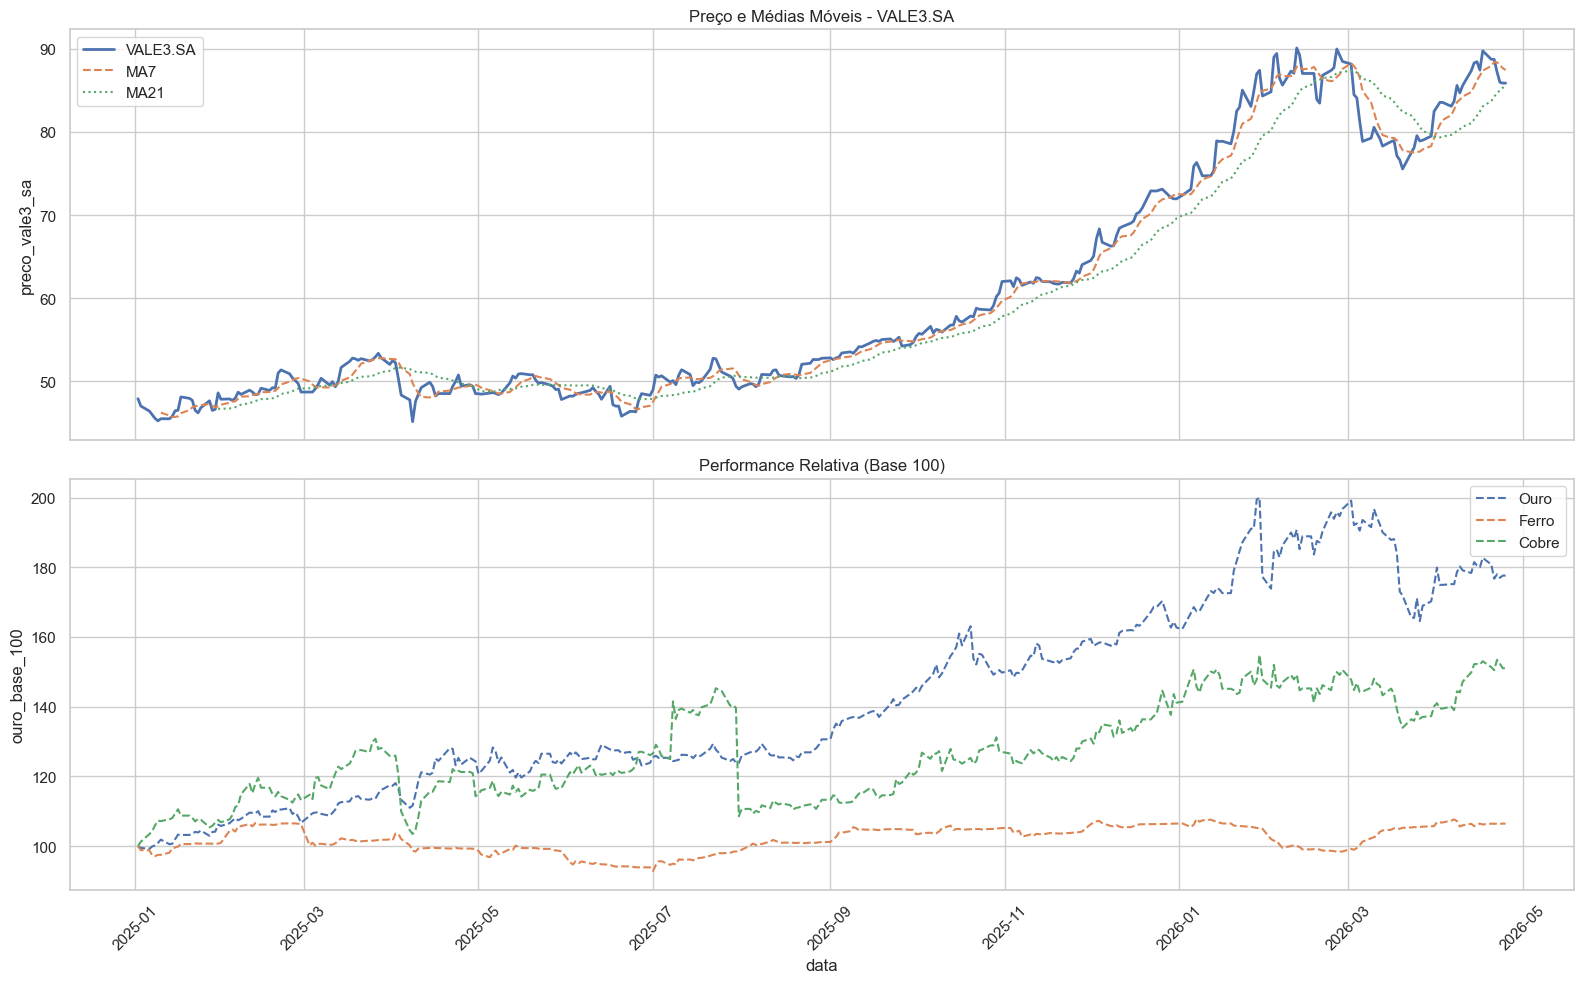

In [33]:
fig, ax = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

sns.lineplot(data=df_eda, x="data", y=target_price_col, ax=ax[0], label=eda_ticker, linewidth=2)
sns.lineplot(data=df_eda, x="data", y="ma7", ax=ax[0], label="MA7", linestyle="--")
sns.lineplot(data=df_eda, x="data", y="ma21", ax=ax[0], label="MA21", linestyle=":")
#sns.lineplot(data=df_eda, x="data", y="cobre", ax=ax[0], label="cobre")
#sns.lineplot(data=df_eda, x="data", y="ouro", ax=ax[0], label="ouro")
ax[0].set_title(f"Preço e Médias Móveis - {eda_ticker}")

#sns.lineplot(data=df_eda, x="data", y="perf_base_100", ax=ax[1], label=eda_ticker)
#sns.lineplot(data=df_eda, x="data", y="peer_base_100", ax=ax[1], label=eda_peer)
#sns.lineplot(data=df_eda, x="data", y="ibov_base_100", ax=ax[1], label="IBOV")
#sns.lineplot(data=df_eda, x="data", y="dolar_base_100", ax=ax[1], label="Dólar")
sns.lineplot(data=df_eda, x="data", y="ouro_base_100", ax=ax[1], label="Ouro", linestyle="--")
sns.lineplot(data=df_eda, x="data", y="ferro_base_100", ax=ax[1], label="Ferro", linestyle="--")
sns.lineplot(data=df_eda, x="data", y="cobre_base_100", ax=ax[1], label="Cobre", linestyle="--")

ax[1].set_title("Performance Relativa (Base 100)")
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


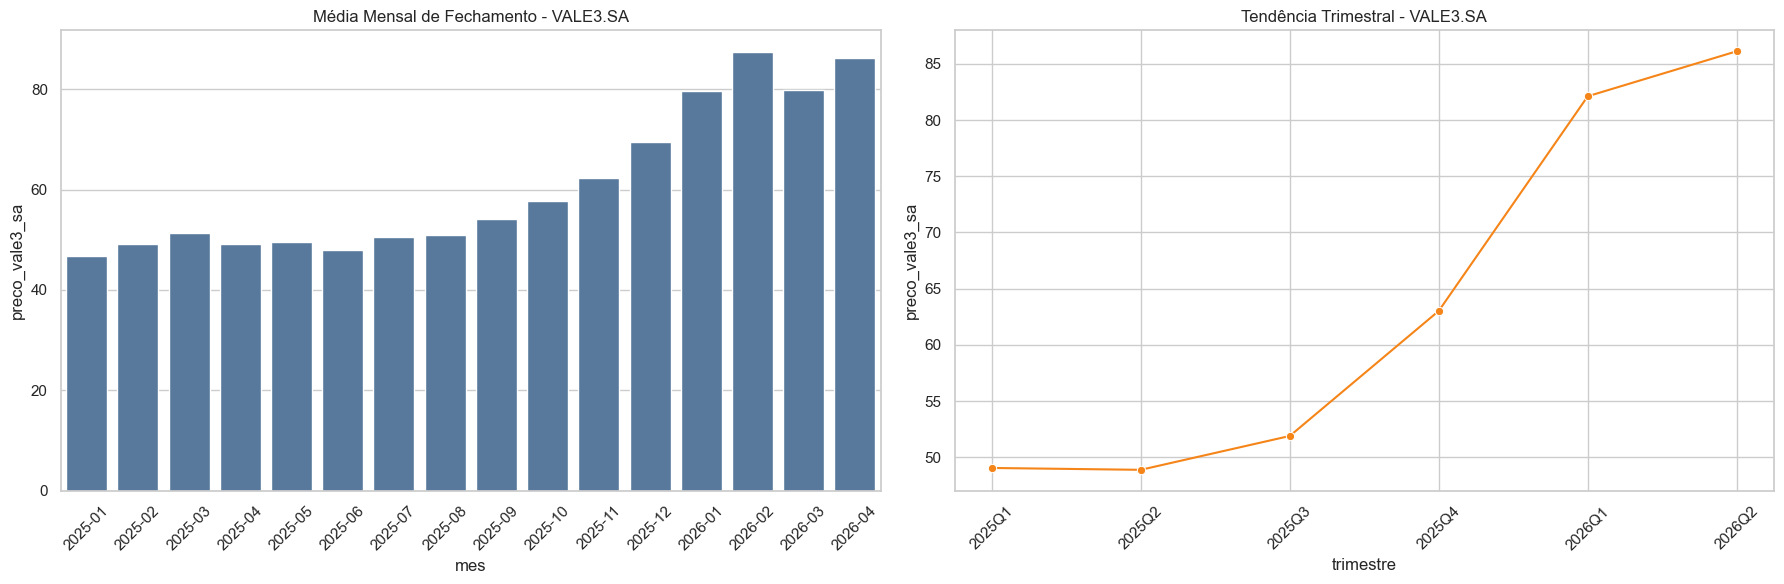

In [34]:
mensal_avg = df_eda.groupby("mes")[target_price_col].mean().reset_index()
trimestral_avg = df_eda.groupby("trimestre")[target_price_col].mean().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=mensal_avg, x="mes", y=target_price_col, ax=ax[0], color="#4C78A8")
ax[0].set_title(f"Média Mensal de Fechamento - {eda_ticker}")
ax[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=trimestral_avg, x="trimestre", y=target_price_col, marker="o", ax=ax[1], color="#F58518")
ax[1].set_title(f"Tendência Trimestral - {eda_ticker}")
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


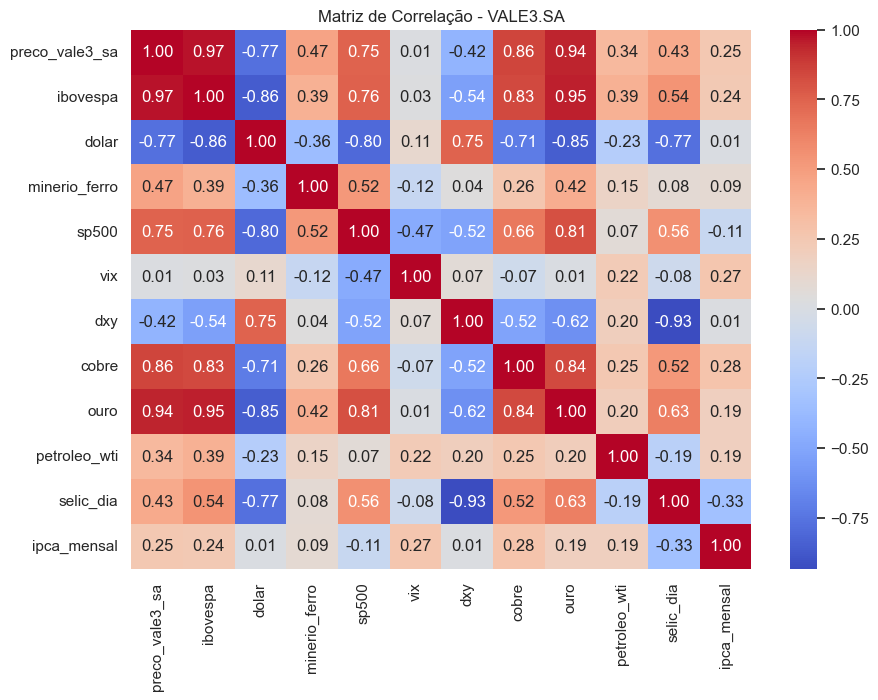

In [36]:
#corr_cols = [target_price_col, peer_price_col, "ibovespa", "dolar", "minerio_ferro", "selic_dia", "ma7", "ma21"]
corr_cols = [target_price_col, *config.DEFAULT_MACRO_COLS]
corr_matrix = df_eda[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title(f"Matriz de Correlação - {eda_ticker}")
plt.show()


## Preparar a base de modelagem

In [5]:
ticker = "VALE3.SA"
ticker_name = 'vale3'
target_col = "target_greater_in_7d"
target_price_col = config.price_column_name(ticker)

df_dataset = load_dataset(config.DEFAULT_DATASET_NAME)
df_model = prepare_modeling_data(df_input=df_dataset, ticker=ticker)

print(df_model.shape)
df_model[["data", "valor_acao", "ma7", "ma21", config.price_column_name("PETR4.SA")]].tail()


(280, 139)


c:\Users\Guilherme\Documents\Projetos\invest-robô\simple_quant\features.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"var_{price_col}_{w}d"] = df[price_col].pct_change(w)
c:\Users\Guilherme\Documents\Projetos\invest-robô\simple_quant\features.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[var_name] = df[col].pct_change(w)
c:\Users\Guilherme\Documents\Projetos\invest-robô\simple_quant\features.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many

,data,valor_acao,ma7,ma21,preco_petr4_sa
335,2026-04-21,88.730003,88.392859,84.240001,46.376369
336,2026-04-22,87.220001,88.372859,84.674287,47.017471
337,2026-04-23,85.970001,88.040002,84.980001,47.770000
338,2026-04-24,85.870003,87.672859,85.311430,47.160000
339,2026-04-25,85.870003,87.448574,85.638573,47.160000


In [6]:
df_dataset.head()

,data,preco_brap4_sa,petroleo_wti,preco_cmin3_sa,preco_csna3_sa,dxy,ouro,preco_ggbr4_sa,preco_goau4_sa,cobre,...,minerio_ferro,dolar,preco_usim5_sa,preco_vale3_sa,ibovespa,sp500,vix,selic_dia,ipca_mensal,ts
0,2025-01-02,13.900052,73.129997,4.462106,8.42,109.389999,2658.899902,17.180902,7.234953,3.9885,...,100.610001,6.3000,5.16,47.932835,120125.0,5868.549805,17.930000,0.045513,NaN,2026-04-26 00:59:17.784905
1,2025-01-03,13.503872,73.959999,4.320452,8.21,108.949997,2645.000000,16.614920,6.977329,4.0395,...,99.440002,6.1510,4.85,47.040447,118533.0,5942.470215,16.129999,0.045513,NaN,2026-04-26 00:59:17.784905
2,2025-01-06,13.546019,73.559998,4.435546,8.53,108.260002,2638.399902,17.296019,7.206328,4.1270,...,99.440002,6.1807,5.09,46.439629,120022.0,5975.379883,16.040001,0.045513,NaN,2026-04-26 00:59:17.784905
3,2025-01-07,13.411148,74.250000,4.265083,8.36,108.540001,2656.699951,17.209681,7.149079,4.1605,...,97.839996,6.1155,5.08,45.989017,121163.0,5909.029785,17.820000,0.045513,NaN,2026-04-26 00:59:17.784905
4,2025-01-08,13.183555,73.320000,4.140164,7.76,109.089996,2664.500000,16.883522,7.005953,4.2275,...,97.739998,6.1009,4.88,45.547237,119625.0,5918.250000,17.700001,0.045513,NaN,2026-04-26 00:59:17.784905


In [7]:
feature_cols_preview = get_feature_columns(df_model)
peer_var_cols = [col for col in feature_cols_preview if col.startswith("var_preco_")]

print("Total de features:", len(feature_cols_preview))
print("Exemplos de features:")
feature_cols_preview[:20]


Total de features: 106
Exemplos de features:


['ma7',
 'ma21',
 'var_acao_7d',
 'var_ma7_7d',
 'var_ma21_7d',
 'var_preco_brap4_sa_7d',
 'var_preco_cmin3_sa_7d',
 'var_preco_csna3_sa_7d',
 'var_preco_ggbr4_sa_7d',
 'var_preco_goau4_sa_7d',
 'var_preco_klbn11_sa_7d',
 'var_preco_petr4_sa_7d',
 'var_preco_prio3_sa_7d',
 'var_preco_suzb3_sa_7d',
 'var_preco_usim5_sa_7d',
 'var_preco_vale3_sa_7d',
 'var_ibovespa_7d',
 'var_dolar_7d',
 'var_minerio_ferro_7d',
 'var_sp500_7d']

In [113]:
'''
feature_cols_preview2 = feature_cols_preview.copy()

for col in feature_cols_preview:
    if ('preco' in col) and (ticker_name not in col):
        pass
    else:
        feature_cols_preview2.remove(col)


df_model = df_model[[target_col, *feature_cols_preview2, 'data']].dropna(

for feature in feature_cols_preview2:
    if 'target' in feature:
        print(feature)
'''

"\nfeature_cols_preview2 = feature_cols_preview.copy()\n\nfor col in feature_cols_preview:\n    if ('preco' in col) and (ticker_name not in col):\n        pass\n    else:\n        feature_cols_preview2.remove(col)\n\n\ndf_model = df_model[[target_col, *feature_cols_preview2, 'data']].dropna(\n\nfor feature in feature_cols_preview2:\n    if 'target' in feature:\n        print(feature)\n"

## Treinar o modelo

In [9]:
df_model[target_col] = df_model[target_col].astype(int)

In [10]:
df_model[target_col].value_counts()

target_greater_in_7d
1    189
0     91
Name: count, dtype: int64

In [11]:
model, metrics, feature_cols = train_model(
    df_model=df_model,
    target_col=target_col,
    train_percent=0.5,
    val_percent=0.3,
    n_iter=20
)


Triple Split: 140 linhas para treino, 77 linhas para validação, 49 linhas para teste
Train: 2025-03-27 00:00:00 to 2025-10-09 00:00:00
Val: 2025-10-21 00:00:00 to 2026-02-06 00:00:00
Test: 2026-02-18 00:00:00 to 2026-04-25 00:00:00


In [12]:
metrics

{'target_col': 'target_greater_in_7d',
 'train_percent': 0.5,
 'val_percent': 0.3,
 'cv_best_score': 0.7336996336996338,
 'val_auc_roc': 0.578512396694215,
 'val_precision': 0.8571428571428571,
 'val_recall': 0.6363636363636364,
 'val_fbeta_0_5': 0.8015267175572519,
 'val_threshold': 0.1,
 'test_auc_roc': 0.7744107744107744,
 'test_precision': 0.7272727272727273,
 'test_recall': 0.7272727272727273,
 'test_fbeta_0_5': 0.7272727272727273,
 'test_threshold': 0.8599999999999995,
 'best_params': {'subsample': 0.8,
  'n_estimators': 200,
  'min_child_weight': 1,
  'max_depth': 4,
  'learning_rate': 0.05,
  'gamma': 0.1,
  'colsample_bytree': 0.7},
 'n_train': 140,
 'n_val': 77,
 'n_test': 49,
 'train_period': {'start': '2025-03-27 00:00:00',
  'end': '2025-10-09 00:00:00'},
 'val_period': {'start': '2025-10-21 00:00:00', 'end': '2026-02-06 00:00:00'},
 'test_period': {'start': '2026-02-18 00:00:00', 'end': '2026-04-25 00:00:00'}}

## Preparar dados de avaliação

In [17]:
horizon = infer_horizon_from_target(target_col)

X_train, y_train, X_test, y_test, feature_cols_eval, train_df, test_df = split_train_test(
    df_model=df_model,
    target_col=target_col,
    split_percent=0.8,
    horizon=horizon,
)

probs = model.predict_proba(X_test)[:, 1]
threshold = metrics["val_threshold"]
preds = (probs > threshold).astype(int)

eval_df = test_df[["data", "preco_vale3_sa", target_col]].copy()
eval_df = eval_df.rename(columns={target_col: "real"}).reset_index(drop=True)
eval_df["prob"] = probs
eval_df["pred"] = preds
eval_df.head()


Split: 224 linhas para treino, 49 linhas para teste
Train: 2025-03-27 00:00:00, 2026-02-06 00:00:00
Test: 2026-02-18 00:00:00, 2026-04-25 00:00:00


,data,preco_vale3_sa,real,prob,pred
0,2026-02-18,83.919998,1,0.524188,1
1,2026-02-19,83.459999,1,0.587570,1
2,2026-02-20,86.809998,0,0.657973,1
3,2026-02-23,87.389999,0,0.714008,1
4,2026-02-24,87.730003,0,0.471444,1


In [18]:
print(f"Ticker: {ticker}")
print(f"Target: {target_col}")
print(f"Coluna alvo de preço: {target_price_col}")
print(f"AUC-ROC teste: {roc_auc_score(y_test, probs):.4f}")
print(f"Threshold selecionado: {threshold:.2f}")
print(f"Total de observações no teste: {len(y_test)}")
print(f"Total de sinais previstos: {preds.sum()}")


Ticker: VALE3.SA
Target: target_greater_in_7d
Coluna alvo de preço: preco_vale3_sa
AUC-ROC teste: 0.7744
Threshold selecionado: 0.10
Total de observações no teste: 49
Total de sinais previstos: 49


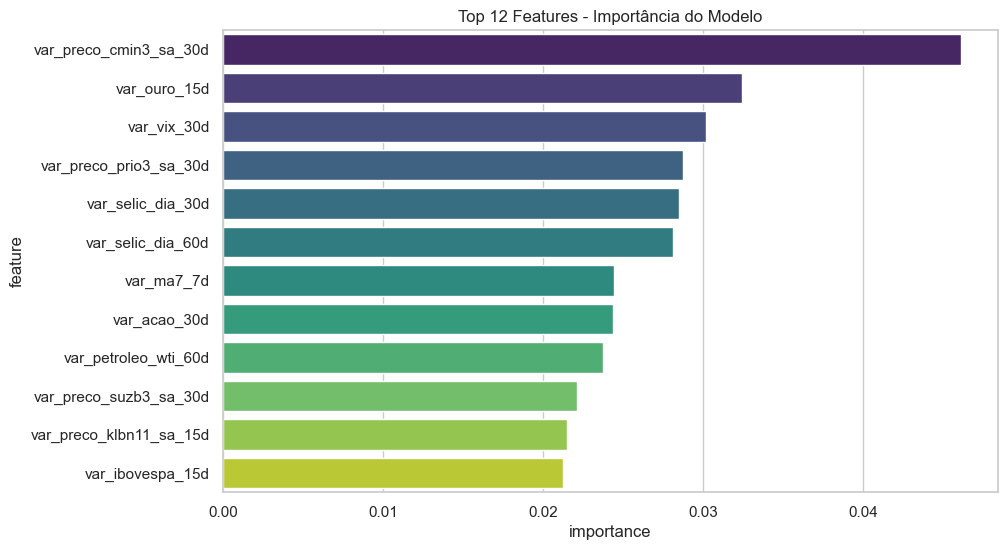

,feature,importance
58,var_preco_cmin3_sa_30d,0.046110
49,var_ouro_15d,0.032452
72,var_vix_30d,0.030171
64,var_preco_prio3_sa_30d,0.028732
77,var_selic_dia_30d,0.028516
103,var_selic_dia_60d,0.028139
3,var_ma7_7d,0.024413
54,var_acao_30d,0.024392
102,var_petroleo_wti_60d,0.023738
65,var_preco_suzb3_sa_30d,0.022105


In [19]:
importance = pd.DataFrame({
    "feature": feature_cols_eval,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(12), x="importance", y="feature", hue="feature", dodge=False, palette="viridis")
plt.title("Top 12 Features - Importância do Modelo")
plt.legend([], [], frameon=False)
plt.show()

importance.head(12)


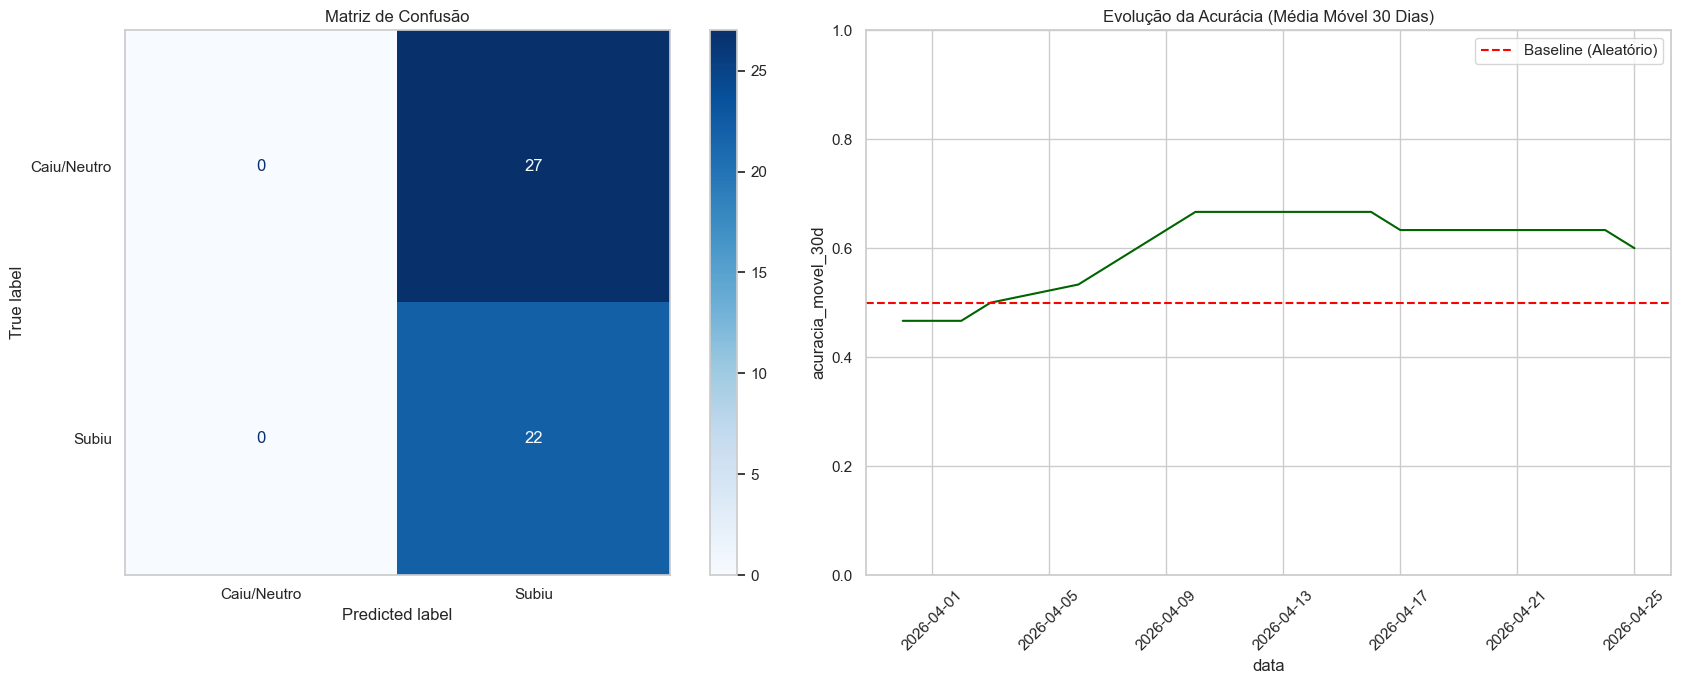

In [20]:
eval_df["acertou"] = (eval_df["real"] == eval_df["pred"]).astype(int)
eval_df["acuracia_movel_30d"] = eval_df["acertou"].rolling(window=30).mean()

fig, ax = plt.subplots(1, 2, figsize=(18, 7))

cm = confusion_matrix(eval_df["real"], eval_df["pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Caiu/Neutro", "Subiu"])
disp.plot(ax=ax[0], cmap="Blues", values_format="d")
ax[0].set_title("Matriz de Confusão")
ax[0].grid(False)

sns.lineplot(data=eval_df, x="data", y="acuracia_movel_30d", ax=ax[1], color="darkgreen")
ax[1].axhline(y=0.5, color="red", linestyle="--", label="Baseline (Aleatório)")
ax[1].set_title("Evolução da Acurácia (Média Móvel 30 Dias)")
ax[1].tick_params(axis="x", rotation=45)
ax[1].set_ylim(0, 1)
ax[1].legend()

plt.tight_layout()
plt.show()


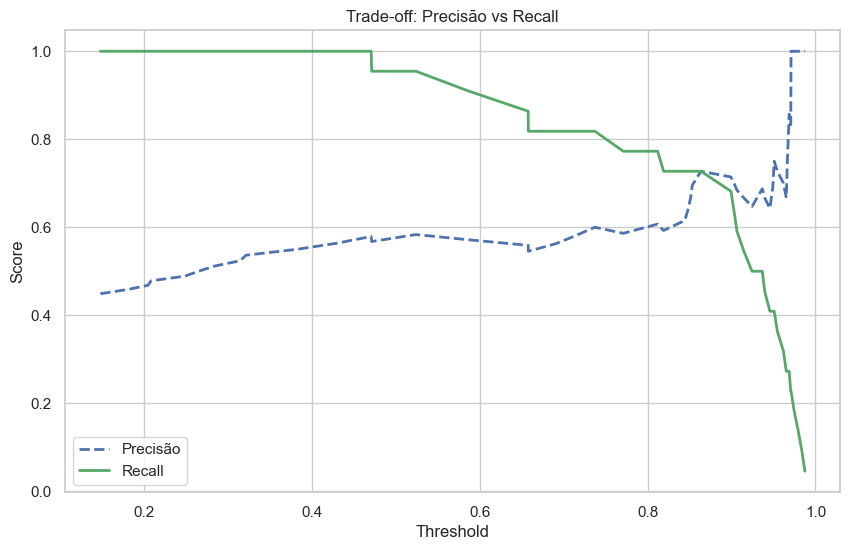

Threshold sugerido pelo F0.5: 0.86
Melhor F0.5: 0.7273


In [ ]:
# melhor corte na base de teste (escolhemos de acordo com a base de treino)

precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], "b--", label="Precisão", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Trade-off: Precisão vs Recall")
plt.legend()
plt.grid(True)
plt.show()

best_threshold, best_f05 = find_best_fbeta_threshold(y_test, probs, beta=0.5)
print(f"Threshold sugerido pelo F0.5: {best_threshold:.2f}")
print(f"Melhor F0.5: {best_f05:.4f}")


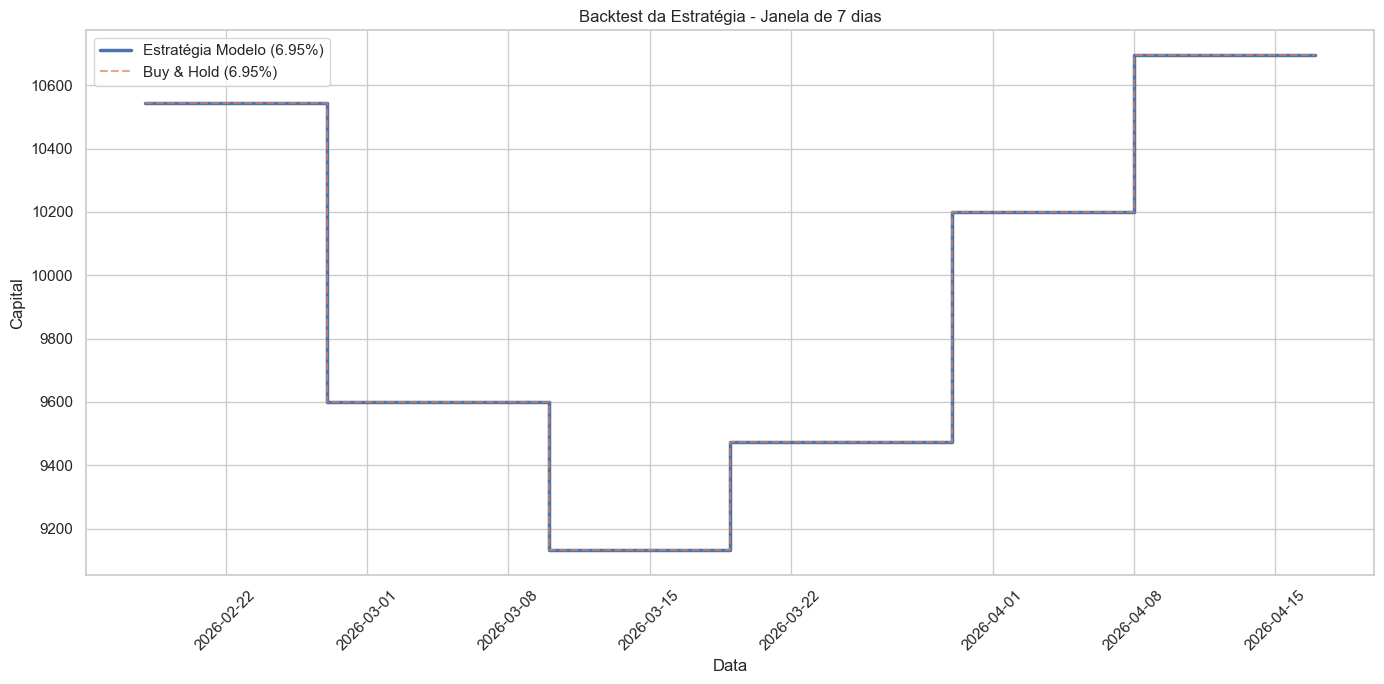

RESULTADO FINAL - JANELA DE 7 DIAS
Retorno Total Modelo:    6.95%
Retorno Total B&H:       6.95%
Alpha (Excesso):         0.00%
Taxa de Acerto (Sinais): 57.14%


,data,preco_vale3_sa,real,pred,retorno_janela,retorno_estrategia,capital_modelo,capital_buy_hold
14,2026-03-10,80.559998,0,1,-0.048784,-0.048784,9131.315411,9131.315411
21,2026-03-19,76.629997,1,1,0.037453,0.037453,9473.308119,9473.308119
28,2026-03-30,79.500000,1,1,0.076604,0.076604,10198.998833,10198.998833
35,2026-04-08,85.589996,1,1,0.048604,0.048604,10694.709480,10694.709480
42,2026-04-17,89.750000,0,1,NaN,NaN,10694.709480,10694.709480


In [24]:
def backtest_model_performance(df_perf, window_days=7, initial_capital=10000):
    df_bt = df_perf[["data", "preco_vale3_sa", "real", "pred"]].copy()
    df_windowed = df_bt.iloc[::window_days, :].copy()
    df_windowed["retorno_janela"] = df_windowed["preco_vale3_sa"].shift(-1) / df_windowed["preco_vale3_sa"] - 1
    df_windowed["retorno_estrategia"] = df_windowed["pred"] * df_windowed["retorno_janela"]
    df_windowed["capital_modelo"] = initial_capital * (1 + df_windowed["retorno_estrategia"].fillna(0)).cumprod()
    df_windowed["capital_buy_hold"] = initial_capital * (1 + df_windowed["retorno_janela"].fillna(0)).cumprod()

    cap_final_modelo = df_windowed["capital_modelo"].iloc[-1]
    cap_final_bh = df_windowed["capital_buy_hold"].iloc[-1]
    ret_total_modelo = ((cap_final_modelo / initial_capital) - 1) * 100
    ret_total_bh = ((cap_final_bh / initial_capital) - 1) * 100
    alpha = ret_total_modelo - ret_total_bh

    ops_realizadas = df_windowed[df_windowed["pred"] == 1]
    hit_rate = (ops_realizadas["real"] == 1).mean() * 100 if len(ops_realizadas) > 0 else 0

    plt.figure(figsize=(14, 7))
    plt.step(df_windowed["data"], df_windowed["capital_modelo"], where="post", label=f"Estratégia Modelo ({ret_total_modelo:.2f}%)", linewidth=2.5)
    plt.step(df_windowed["data"], df_windowed["capital_buy_hold"], where="post", label=f"Buy & Hold ({ret_total_bh:.2f}%)", linestyle="--", alpha=0.7)
    plt.title(f"Backtest da Estratégia - Janela de {window_days} dias")
    plt.xlabel("Data")
    plt.ylabel("Capital")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("=" * 55)
    print(f"RESULTADO FINAL - JANELA DE {window_days} DIAS")
    print("=" * 55)
    print(f"Retorno Total Modelo:    {ret_total_modelo:.2f}%")
    print(f"Retorno Total B&H:       {ret_total_bh:.2f}%")
    print(f"Alpha (Excesso):         {alpha:.2f}%")
    print(f"Taxa de Acerto (Sinais): {hit_rate:.2f}%")
    print("=" * 55)
    return df_windowed


df_backtest = backtest_model_performance(eval_df, window_days=horizon, initial_capital=10000)
df_backtest.tail()


## Salvar artefatos e registrar o modelo

In [25]:
model_name = f"{ticker.replace('.', '_')}_{target_col}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

artifact_dir = save_model_artifacts(
    model=model,
    model_name=model_name,
    ticker=ticker,
    target_col=target_col,
    target_price_col=target_price_col,
    feature_cols=feature_cols,
    metrics=metrics,
)


In [26]:
artifact_dir

WindowsPath('C:/Users/Guilherme/Documents/Projetos/invest-robô/models/VALE3_SA_target_greater_in_7d_20260426_013138')

In [28]:

save_model_record(
    model_name=model_name,
    ticker=ticker,
    target_col=target_col,
    artifact_path=str(artifact_dir),
    features=feature_cols,
    threshold=metrics["val_threshold"],
)

print("Artefatos salvos em:", artifact_dir)


Artefatos salvos em: C:\Users\Guilherme\Documents\Projetos\invest-robô\models\VALE3_SA_target_greater_in_7d_20260426_013138


## Escorar a última linha disponível

In [9]:
list_models()['artifact_path'].iloc[0]


'C:\\Users\\Guilherme\\Documents\\Projetos\\invest-robô\\models\\VALE3_SA_target_greater_in_7d_20260426_013138'

In [ ]:
artifact_dir = list_models()['artifact_path'].iloc[0] #'C:\\Users\\Guilherme\\Documents\\Projetos\\invest-robô\\models\\VALE3_SA_target_greater_in_7d_20260426_013138'

In [11]:
loaded_model, metadata = load_model_artifacts(artifact_dir)

In [12]:
loaded_model

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [13]:
metadata

{'model_name': 'VALE3_SA_target_greater_in_7d_20260426_013138',
 'ticker': 'VALE3.SA',
 'target_col': 'target_greater_in_7d',
 'target_price_col': 'preco_vale3_sa',
 'feature_cols': ['ma7',
  'ma21',
  'var_acao_7d',
  'var_ma7_7d',
  'var_ma21_7d',
  'var_preco_brap4_sa_7d',
  'var_preco_cmin3_sa_7d',
  'var_preco_csna3_sa_7d',
  'var_preco_ggbr4_sa_7d',
  'var_preco_goau4_sa_7d',
  'var_preco_klbn11_sa_7d',
  'var_preco_petr4_sa_7d',
  'var_preco_prio3_sa_7d',
  'var_preco_suzb3_sa_7d',
  'var_preco_usim5_sa_7d',
  'var_preco_vale3_sa_7d',
  'var_ibovespa_7d',
  'var_dolar_7d',
  'var_minerio_ferro_7d',
  'var_sp500_7d',
  'var_vix_7d',
  'var_dxy_7d',
  'var_cobre_7d',
  'var_ouro_7d',
  'var_petroleo_wti_7d',
  'var_selic_dia_7d',
  'var_ipca_mensal_7d',
  'ratio_acao_vs_macro_7d',
  'var_acao_15d',
  'var_ma7_15d',
  'var_ma21_15d',
  'var_preco_brap4_sa_15d',
  'var_preco_cmin3_sa_15d',
  'var_preco_csna3_sa_15d',
  'var_preco_ggbr4_sa_15d',
  'var_preco_goau4_sa_15d',
  'var_pre

In [31]:

X_row, latest_row = get_scoring_row(
    df_model=df_model,
    feature_cols=metadata["feature_cols"],
    as_of_date=None,
)

In [47]:
latest_row.data

Timestamp('2026-04-25 00:00:00')

In [43]:


result = score_row(
    model=loaded_model,
    X_row=X_row,
    threshold=float(metadata.get("threshold", metrics['val_threshold'])),
)

result


{'probability': 0.6907444596290588, 'prediction': 1}

In [54]:
#as_of_date = latest_row["data"].strftime("%Y-%m-%d")
as_of_date = latest_row['data'].strftime("%Y-%m-%d")

save_score_row(
    model_name=metadata["model_name"],
    ticker=metadata["ticker"],
    target_col=metadata["target_col"],
    probability=result["probability"],
    prediction=result["prediction"],
    as_of_date=as_of_date,
)

print("Score salvo para", metadata["ticker"], "em", as_of_date)


Score salvo para VALE3.SA em 2026-04-25


In [55]:
list_scores(model_name=metadata["model_name"]).head()


,id,model_name,ticker,target_col,probability,prediction,as_of_date,scored_at
0,7,VALE3_SA_target_greater_in_7d_20260426_013138,VALE3.SA,target_greater_in_7d,0.690744,1,2026-04-25,2026-04-26T01:47:40.194476


In [56]:
list_models()

,model_name,ticker,target_col,artifact_path,features_json,threshold,created_at
0,VALE3_SA_target_greater_in_7d_20260426_013138,VALE3.SA,target_greater_in_7d,C:\Users\Guilherme\Documents\Projetos\invest-r...,"[""ma7"", ""ma21"", ""var_acao_7d"", ""var_ma7_7d"", ""...",0.10,2026-04-26T01:32:20.923229
1,VALE3_SA_target_greater_in_7d_20260424_002321,VALE3.SA,target_greater_in_7d,C:\Users\Guilherme\Documents\Projetos\invest-r...,"[""ma7"", ""ma21"", ""var_acao_7d"", ""var_ma7_7d"", ""...",0.81,2026-04-24T00:23:21.780909
2,VALE3_SA_target_greater_in_7d_20260424_001950,VALE3.SA,target_greater_in_7d,C:\Users\Guilherme\Documents\Projetos\invest-r...,"[""ma7"", ""ma21"", ""var_acao_7d"", ""var_ibovespa_7...",0.75,2026-04-24T00:19:50.945922
3,VALE3_SA_target_greater_in_7d_20260424_000714,VALE3.SA,target_greater_in_7d,C:\Users\Guilherme\Documents\Projetos\invest-r...,"[""ma7"", ""ma21"", ""var_acao_7d"", ""var_ma7_7d"", ""...",0.81,2026-04-24T00:07:14.435708
4,VALE3_SA_target_greater_in_7d_20260423_233622,VALE3.SA,target_greater_in_7d,C:\Users\Guilherme\Documents\Projetos\invest-r...,"[""ma7"", ""ma21"", ""var_acao_7d"", ""var_ma7_7d"", ""...",0.79,2026-04-23T23:36:22.849963
5,VALE3_SA_target_greater_in_7d_20260423_231900,VALE3.SA,target_greater_in_7d,C:\Users\Guilherme\Documents\Projetos\invest-r...,"[""ma7"", ""ma21"", ""var_acao_7d"", ""var_ma7_7d"", ""...",0.88,2026-04-23T23:19:00.982915
6,VALE3_SA_target_greater_in_7d_20260423_224042,VALE3.SA,target_greater_in_7d,C:\Users\Guilherme\Documents\Projetos\invest-r...,"[""ma7"", ""ma21"", ""var_acao_7d"", ""var_ibovespa_7...",0.45,2026-04-23T22:40:42.879242
